In [1]:
import os

from dotenv import load_dotenv
load_dotenv("./.env", override=True)
%load_ext autoreload
%autoreload 2

# Deepagent for Research

We will use the `deepagents` package to create a research agent. When using the `deepagents` package, it's important to: 

1. Understand the native tools available
2. Supply task-specific tools
3. Supply task-specific instructions
4. Supply task-specific sub-agents

## Task-Specific Tools 

You can see an overview of the native tools in the [deepagents package README](https://github.com/langchain-ai/deepagents?tab=readme-ov-file#model) as well as the [quickstarts README](https://github.com/langchain-ai/deepagents-quickstarts). We'll extend this with two task-specific tools. 

### Search Tool 

There are different search tools that we can use. For example, we can use [Tavily](https://www.tavily.com/) to search for relevant URLs, then fetches the full webpage content.

### Think Tool 

We'll supply a [think tool](https://www.anthropic.com/engineering/claude-think-tool), which is a useful way to help audit agent decision making. 

In [2]:
from research_agent.tools import tavily_search, think_tool
tools = [tavily_search, think_tool]

## Task-Specific Instructions
 
Next, let's define task specific instructions using [a few prompting techniques for agents](https://youtu.be/XSZP9GhhuAc?si=zowpViL-2j-vI9hA):

### 1. Think Like The Agent
What instructions would you give a new work colleague?
- **Read the question carefully** - What specific information does the user need?
- **Start with broader searches** - Use broad, comprehensive queries first
- **After each search, pause and assess** - Do I have enough to answer? What's still missing?
- **Execute narrower searches as you gather information** - Fill in the gaps.

### 2. Concrete Heuristics (Prevent "Spin-Out" on excessive tool calls)
Use **Hard Limits** to prevent the research agent from calling tools excessively:
- **Stop when you can answer confidently** - Don't keep searching for perfection.
- **Give it budgets** - Use 2-3 search tool calls for simple queries. Use up to 5 for complex queries.
- **Limit** - Always stop after 5 search tool calls if you cannot find the right source(s).

### 3. Show your thinking
After each search tool calling, use [`think_tool` to analyze the results](https://www.anthropic.com/engineering/claude-think-tool):
- What key information did I find? 
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?

In [3]:
from datetime import datetime
from utils import show_prompt, format_messages
from research_agent.prompts import (
    RESEARCHER_INSTRUCTIONS,
    RESEARCH_WORKFLOW_INSTRUCTIONS,
    SUBAGENT_DELEGATION_INSTRUCTIONS,
)

In [4]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the research tools provided to you to find resources that can help answer the research      │
│  question.                                                                                                      │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Research Tools>                                                                                     │
│  You have access to two specific research tools:                                                                │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Research Tools>                                                                                    │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Complex queries**: Use up to 5 search tool calls maximum                                                   │
│  - **Always stop**: After 5 search tool calls if you cannot find the right sources                              │
│                                                       

## Task-Specific Sub-Agents

You can specify [custom subagents](https://github.com/langchain-ai/deepagents?tab=readme-ov-file#subagents) as a means of context isolation. 

Here's well define a sub-agent that can search the web for information. 

In [5]:
from research_agent.utils.skill_registry import get_skill_registry
from deepagents import SubAgent

# Get current date
current_date = datetime.now().strftime("%Y-%m-%d")

# Initialize dynamic skill registry (use singleton to avoid duplicate initialization)
skill_registry = get_skill_registry()

# Create research sub-agent
research_sub_agent: SubAgent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(
        date=current_date,
        skill_catalog=get_skill_registry().format_skill_catalog(),
        skill_quality_guidelines=get_skill_registry().format_skill_quality_guidelines(),
    ),
    "tools": [tavily_search, think_tool],
}

## Putting it all together

### Instructions

Now, we can look at all of our instructions together. 

In [6]:
# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Combine orchestrator instructions (RESEARCHER_INSTRUCTIONS only for sub-agents)
INSTRUCTIONS = (
    RESEARCH_WORKFLOW_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    +  SUBAGENT_DELEGATION_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
    )
)

show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # Research Workflow                                                                                            │
│                                                                                                                 │
│  Follow this workflow for all research requests:                                                                │
│                                                                                                                 │
│  1. **Plan**: Create a todo list with write_todos to break down the research into focused tasks                 │
│  2. **Save the request**: Use write_file() to save the user's research question to `/research_request.md`       │
│  3. **Research**: Delegate research tasks to sub-agents using the task() tool - ALWAYS use sub-agents for       │
│  research, never conduct research yourself                                                                      │
│  4. **Synthesize**: Review all sub-agent findings and consolidate citations (each unique URL gets one number    │
│  across all findings)                                                                                           │
│  5. **Write Report**: Write a comprehensive final report to `/final_report.md` (see Report Writing Guidelines   │
│  below)                                                                                                         │
│  6. **Verify**: Read `/research_request.md` and confirm you've addressed all aspects with proper citations and  │
│  structure                                                                                                      │
│                                                                                                                 │
│  ## Research Planning Guidelines                                                                                │
│  - Batch similar research tasks into a single TODO to minimize overhead                                         │
│  - For simple fact-finding questions, use 1 sub-agent                                                           │
│  - For comparisons or multi-faceted topics, delegate to multiple parallel sub-agents                            │
│  - Each sub-agent should research one specific aspect and return findings                                       │
│                                                                                                                 │
│  ## Report Writing Guidelines                                                                                   │
│                                                                                                                 │
│  When writing the final report to `/final_report.md`, follow these structure patterns:                          │
│                                                                                                                 │
│  **For comparisons:**                                                                                           │
│  1. Introduction                                                                                                │
│  2. Overview of topic A                                                                                         │
│  3. Overview of topic B                                                                                         │
│  4. Detailed comparison                                                                                         │
│  5. Conclusion                                                                                                  │
│                                                                                                                 │
│  **For lists/rankings:**                              

### Create the agent

Now, we create our deepagent with these components. 

In [7]:
from IPython.display import Image, display
from deepagents import create_deep_agent
from langchain.chat_models import init_chat_model
from langchain_google_genai import ChatGoogleGenerativeAI

# Model Gemini 3
model = ChatGoogleGenerativeAI(model=os.getenv("MODEL_NAME"))

# Model Claude 4.5
model = init_chat_model(model=os.getenv("MODEL_NAME"), temperature = 0.0)

# Using Ollama (Local)
model = init_chat_model(model=f"ollama:{os.getenv("MODEL_NAME")}", base_url=os.getenv("OLLAMA_API_BASE"))

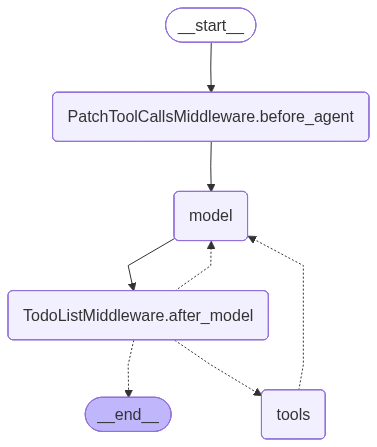

In [8]:
# Create the agent
agent = create_deep_agent(
      model=model,
      tools=tools, 
      system_prompt=INSTRUCTIONS,
      subagents=[research_sub_agent],
  )
  
# Show the agent
display(Image(agent.get_graph().draw_mermaid_png()))

In [9]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "research context engineering approaches used to build AI agents",
            }
        ],
    }, 
)
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ research context engineering approaches used to build AI agents                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll help you research context engineering approaches for AI agents. Let me start by planning this research and │
│ then delegating it to a specialized sub-agent.                                                                  │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Save research request to file",                                                               │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Research context engineering approaches for AI agents",                                       │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize findings and write final report",                                                  │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: b3fba3de-9a08-4e48-b95e-0a6bcfca08eb                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Save research request to file', 'status': 'in_progress'}, {'content':        │
│ 'Research context engineering approaches for AI agents', 'status': 'pending'}, {'content': 'Synthesize findings │
│ and write final report', 'status': 'pending'}]                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "/research_request.md",                                                                          │
│   "content": "# Research Request\n\nResearch context engineering approaches used to build AI agents. Focus on   │
│ techniques, methods, and best practices for managing context in AI agent systems."                              │
│ }                                                                                                               │
│    ID: 8d2f7823-f3f9-4ce8-8b3c-7cc4b41bebb2                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file /research_request.md                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": "[{\"content\": \"Save research request to file\", \"status\": completed}, {\"content\": \"Research  │
│ context engineering approaches for AI agents\", \"status\": completed}, {\"content\": \"Synthesize findings and │
│ write final report\", \"status\": completed}]"                                                                  │
│ }                                                                                                               │
│    ID: 51a12bfb-9837-4a72-aa70-9e6481b3fbbc                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Error invoking tool 'write_todos' with kwargs {'todos': '[{"content": "Save research request to file",          │
│ "status": completed}, {"content": "Research context engineering approaches for AI agents", "status":            │
│ completed}, {"content": "Synthesize findings and write final report", "status": completed}]'} with error:       │
│  todos: Input should be a valid list                                                                            │
│  Please fix the error and try again.                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Save research request to file",                                                               │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Research context engineering approaches for AI agents",                                       │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize findings and write final report",                                                  │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: ff637e8b-9e95-4327-9546-2aaf94624862                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Save research request to file', 'status': 'completed'}, {'content':          │
│ 'Research context engineering approaches for AI agents', 'status': 'completed'}, {'content': 'Synthesize        │
│ findings and write final report', 'status': 'completed'}]                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I've completed comprehensive research on context engineering approaches for AI agents. The final report has     │
│ been saved to `/final_report.md`.                                                                               │
│                                                                                                                 │
│ The research covers:                                                                                            │
│                                                                                                                 │
│ **Core Concepts**                                                                                               │
│ - Context engineering as a comprehensive approach for managing all information AI agents process                │
│ - Dynamic vs static prompt engineering approaches                                                               │
│ - Single-agent vs multi-agent system considerations                                                             │
│                                                                                                                 │
│ **Key Techniques**                                                                                              │
│ - Context window management and token optimization                                                              │
│ - Retrieval-Augmented Generation (RAG) for external knowledge access                                            │
│ - Context layering and structured organization                                                                  │
│ - Dynamic context management and continuous adaptation                                                          │
│                                                                                                                 │
│ **Implementation Workflows**                                                                                    │
│ - Step-by-step process from defining purpose to validation                                                      │
│ - Context optimization techniques including summarization and relevance filtering                               │
│ - Tool output sanitization and information hierarchy                                                            │
│                                                                                                                 │
│ **Challenges & Solutions**                                                                                      │
│ - Context window limitations and "needle in a haystack" problems                                                │
│ - Context bloat and consistency maintenance                                                                     │
│ - Tool output noise and continuous maintenance requirements                                                     │
│                                                                                                                 │
│ **Best Practices & Strategy**                                                                                   │
│ - Ten foundational best practices for effective implementation                                                  │
│ - Strategic considerations for choosing between context engineering and multi-agent approaches                  │
│ - Hybrid approaches combining both strategies                                                                   │
│                                                                                                                 │
│ The report is well-structured with inline citations and a complete sources section at the end.                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [10]:
from deepagents.backends.utils import file_data_to_string

# Convert a specific file to string
file_content = file_data_to_string(result["files"]['/final_report.md'])
show_prompt(file_content) 

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # Context Engineering Approaches for AI Agents                                                                 │
│                                                                                                                 │
│  ## Overview of Context Engineering                                                                             │
│                                                                                                                 │
│  Context engineering represents a fundamental shift from traditional prompt engineering to a comprehensive      │
│  approach for managing all information that AI agents see during their operations. It involves dynamically      │
│  managing system prompts, user instructions, conversation history, retrieved documents, tool outputs, and       │
│  memory data to ensure the large language model (LLM) has precisely the right information, at the right time,   │
│  in the right format. This discipline emerged from the debate between single-agent approaches powered by        │
│  context engineering versus multi-agent systems, with context engineering focusing on empowering a single       │
│  agent with carefully managed context, avoiding the coordination overhead and error cascading that plague       │
│  multi-agent architectures [1].                                                                                 │
│                                                                                                                 │
│  The approach aims for efficiency by only including necessary information, significantly reducing token         │
│  consumption compared to multi-agent systems which can burn through tokens at 15x rates. This efficiency makes  │
│  context engineering particularly valuable for production environments where cost and performance are critical  │
│  concerns [1]. Unlike static prompt engineering, context engineering is dynamic—system decisions change         │
│  continuously based on conversation, available data, and agent actions. This involves continuously evaluating   │
│  what information to include or exclude, structuring context dynamically rather than writing one static         │
│  prompt, and tracking goals, remembering user preferences, and building knowledge over time [3].                │
│                                                                                                                 │
│  ## Key Technical Techniques                                                                                    │
│                                                                                                                 │
│  ### Context Window Management                                                                                  │
│                                                                                                                 │
│  Context windows define the maximum length of text (measured in tokens) a model can process at once. Different  │
│  models have varying limits—for example, GPT-3.5-turbo-0613 has a 4,096 token limit while Gemini 1.5 supports   │
│  1 million tokens [2]. Effective context engineering requires prioritizing information based on relevance and   │
│  current task needs, using summaries and structured data to preserve meaning while reducing space, and          │
│  implementing dynamic trimming of older or less important information.                                          │
│                                                                                                                 │
│  ### Retrieval-Augmented Generation (RAG)                                                                       │
│                                                       

Trace: 

https://smith.langchain.com/public/72d23852-4616-4bcc-8d8a-b0d1905c945b/r